Минимум f1: x = 1.000000,  f1(x) = -5.416667
Максимум f2: x = -2.015446,  f2(x) = 1.003876

=== ДИСКРЕТНЫЙ ВАРИАНТ ===
Прибор 1   x= -4.00   f1=  671.6667   f2= -142.0000
Прибор 2   x= -2.00   f1=  154.3333   f2=    1.0000 [Парето]
Прибор 3   x=  0.00   f1=    5.0000   f2=  -16.0000
Прибор 4   x=  2.00   f1=   -0.3333   f2=   -1.0000 [Парето]
Прибор 5   x=  4.00   f1=   10.3333   f2= -146.0000
Лучшая дискретная точка: x = 2.000000

=== НЕПРЕРЫВНЫЙ ВАРИАНТ ===
Веса: λ1 = 0.50, λ2 = 0.50
Компромисс: x = 1.984188
f1(x*) = -0.459572
f2(x*) = -0.996063
rho(x*) = 0.002250


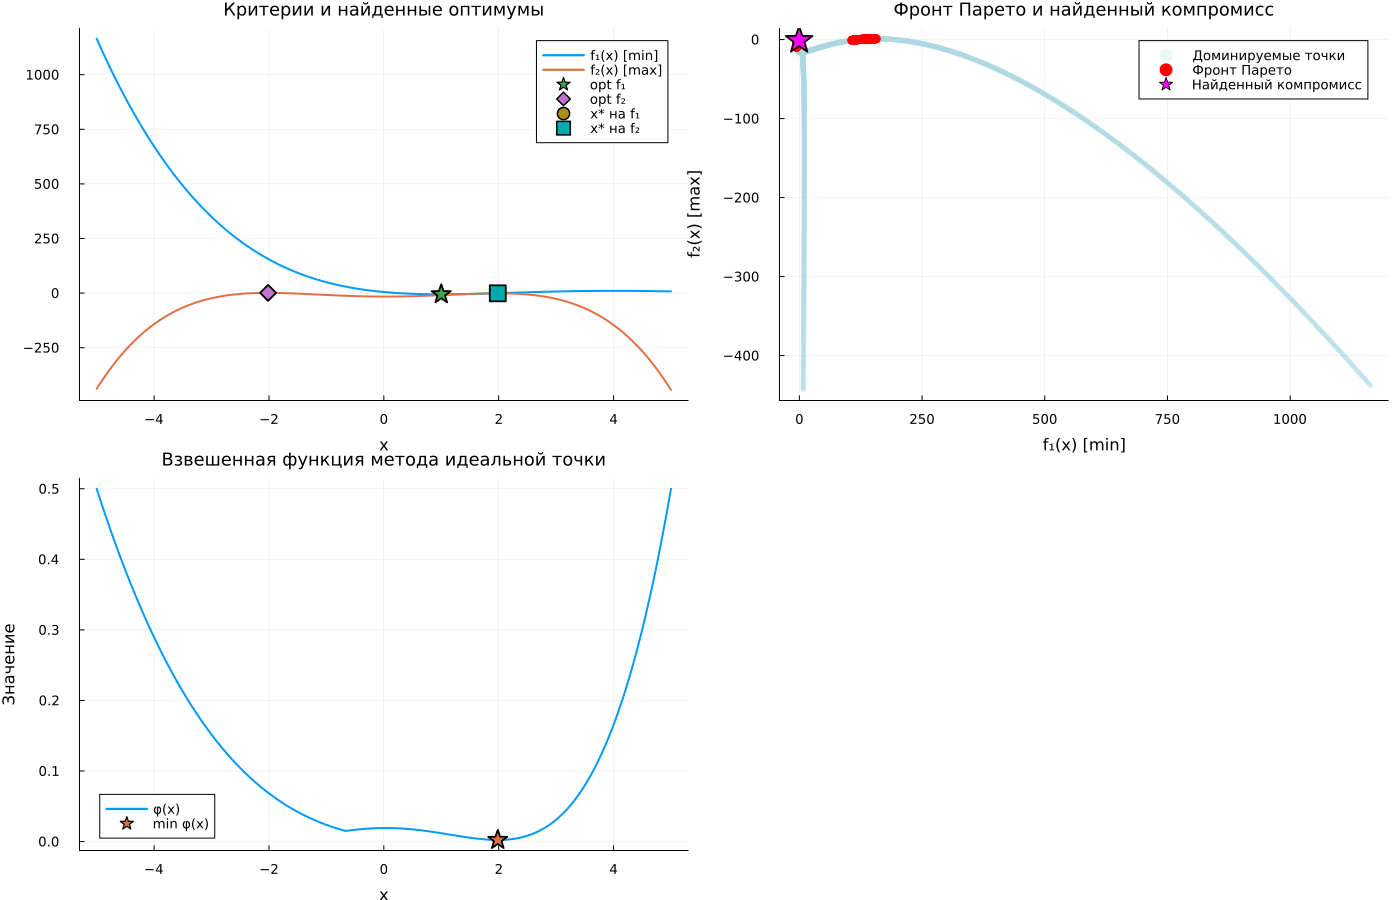

In [4]:
using Printf, Plots

gr()

f1(x) = 5 - 24x + 17x^2 - (11/3)*x^3 + (1/4)*x^4
f2(x) = -((x^2 - 4)^2 + x/2)

a, b = -5.0, 5.0

x_disc = [-4.0, -2.0, 0.0, 2.0, 4.0]
names_disc = ["Прибор 1", "Прибор 2", "Прибор 3", "Прибор 4", "Прибор 5"]

λ1 = 0.5
λ2 = 0.5

function min_to_utility(v)
    vmin, vmax = minimum(v), maximum(v)
    if isapprox(vmax, vmin; atol=1e-12)
        return fill(1.0, length(v))
    end
    return (vmax .- v) ./ (vmax - vmin)
end

function max_to_utility(v)
    vmin, vmax = minimum(v), maximum(v)
    if isapprox(vmax, vmin; atol=1e-12)
        return fill(1.0, length(v))
    end
    return (v .- vmin) ./ (vmax - vmin)
end

function dominates_mixed(a::Tuple{Float64,Float64}, b::Tuple{Float64,Float64})
    return (a[1] <= b[1] && a[2] >= b[2]) && (a[1] < b[1] || a[2] > b[2])
end

function pareto_mask_mixed(f1vals, f2vals)
    n = length(f1vals)
    mask = trues(n)
    pts = [(Float64(f1vals[i]), Float64(f2vals[i])) for i in 1:n]
    for i in 1:n
        for j in 1:n
            if i != j && dominates_mixed(pts[j], pts[i])
                mask[i] = false
                break
            end
        end
    end
    return mask
end

function golden_section_min(phi, a, b; tol=1e-8, max_iter=10_000)
    ρ = (sqrt(5) - 1) / 2
    c = b - ρ * (b - a)
    d = a + ρ * (b - a)
    fc, fd = phi(c), phi(d)

    k = 0
    while abs(b - a) > tol && k < max_iter
        if fc < fd
            b, d, fd = d, c, fc
            c = b - ρ * (b - a)
            fc = phi(c)
        else
            a, c, fc = c, d, fd
            d = a + ρ * (b - a)
            fd = phi(d)
        end
        k += 1
    end

    xopt = (a + b) / 2
    return xopt, phi(xopt)
end

n_grid = 4000
xg = collect(range(a, b; length=n_grid))
f1g = [f1(x) for x in xg]
f2g = [f2(x) for x in xg]

u1g = min_to_utility(f1g)
u2g = max_to_utility(f2g)

f1min, f1max = minimum(f1g), maximum(f1g)
f2min, f2max = minimum(f2g), maximum(f2g)

u1_of_x(x) = isapprox(f1max, f1min; atol=1e-12) ? 1.0 : (f1max - f1(x)) / (f1max - f1min)
u2_of_x(x) = isapprox(f2max, f2min; atol=1e-12) ? 1.0 : (f2(x) - f2min) / (f2max - f2min)

x_f1, f1_best = golden_section_min(f1, a, b)
x_f2, _ = golden_section_min(x -> -f2(x), a, b)
f2_best = f2(x_f2)

f1_disc = [f1(x) for x in x_disc]
f2_disc = [f2(x) for x in x_disc]

u1_disc = min_to_utility(f1_disc)
u2_disc = max_to_utility(f2_disc)

rho_disc = [
    sqrt((λ1 * (1 - u1_disc[i]))^2 + (λ2 * (1 - u2_disc[i]))^2)
    for i in eachindex(x_disc)
]

best_disc_idx = argmin(rho_disc)
pareto_disc = pareto_mask_mixed(f1_disc, f2_disc)

phi(x) = max(λ1 * abs(1 - u1_of_x(x)), λ2 * abs(1 - u2_of_x(x)))

x_star, rho_star = golden_section_min(phi, a, b)
f1_star, f2_star = f1(x_star), f2(x_star)
u1_star, u2_star = u1_of_x(x_star), u2_of_x(x_star)

pareto_cont = pareto_mask_mixed(f1g, f2g)

@printf("Минимум f1: x = %.6f,  f1(x) = %.6f\n", x_f1, f1_best)
@printf("Максимум f2: x = %.6f,  f2(x) = %.6f\n\n", x_f2, f2_best)

println("=== ДИСКРЕТНЫЙ ВАРИАНТ ===")
for i in eachindex(x_disc)
    mark = pareto_disc[i] ? " [Парето]" : ""
    @printf("%-9s  x=%6.2f   f1=%10.4f   f2=%10.4f%s\n",
        names_disc[i], x_disc[i], f1_disc[i], f2_disc[i], mark)
end
@printf("Лучшая дискретная точка: x = %.6f\n\n", x_disc[best_disc_idx])

println("=== НЕПРЕРЫВНЫЙ ВАРИАНТ ===")
@printf("Веса: λ1 = %.2f, λ2 = %.2f\n", λ1, λ2)
@printf("Компромисс: x = %.6f\n", x_star)
@printf("f1(x*) = %.6f\n", f1_star)
@printf("f2(x*) = %.6f\n", f2_star)
@printf("rho(x*) = %.6f\n", rho_star)

default(
    linewidth = 2,
    markersize = 6,
    legendfontsize = 9,
    guidefontsize = 11,
    tickfontsize = 9,
    titlefontsize = 12,
    size = (1400, 900)
)

p1 = plot(
    xg, f1g,
    label = "f₁(x) [min]",
    xlabel = "x",
    ylabel = "Значение",
    title = "Критерии и найденные оптимумы"
)
plot!(p1, xg, f2g, label = "f₂(x) [max]")

scatter!(p1, [x_f1], [f1_best], marker=:star5, markersize=10, label="opt f₁")
scatter!(p1, [x_f2], [f2_best], marker=:diamond, markersize=8, label="opt f₂")
scatter!(p1, [x_star], [f1_star], marker=:circle, markersize=8, label="x* на f₁")
scatter!(p1, [x_star], [f2_star], marker=:square, markersize=8, label="x* на f₂")

dom_mask = .!pareto_cont

p2 = scatter(
    f1g[dom_mask], f2g[dom_mask],
    color = :lightblue,
    alpha = 0.25,
    markersize = 3,
    markerstrokewidth = 0,
    label = "Доминируемые точки",
    xlabel = "f₁(x) [min]",
    ylabel = "f₂(x) [max]",
    title = "Фронт Парето и найденный компромисс"
)

pareto_idx = findall(pareto_cont)

scatter!(
    p2,
    f1g[pareto_idx], f2g[pareto_idx],
    color = :red,
    markerstrokecolor = :red,
    markerstrokewidth = 0,
    markersize = 5,
    label = "Фронт Парето"
)

scatter!(
    p2,
    [f1_star], [f2_star],
    marker = :star5,
    color = :magenta,
    markerstrokecolor = :black,
    markerstrokewidth = 1,
    markersize = 14,
    label = "Найденный компромисс"
)

phig = [phi(x) for x in xg]

p3 = plot(
    xg, phig,
    label = "φ(x)",
    xlabel = "x",
    ylabel = "Значение",
    title = "Взвешенная функция метода идеальной точки"
)

scatter!(
    p3,
    [x_star], [rho_star],
    marker = :star5,
    markersize = 10,
    label = "min φ(x)"
)

plt = plot(p1, p2, p3, layout=(2,2), size=(1400, 900))
display(plt)